In [ ]:
import torch.nn as nn
import torch.optim as optim
import math
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import random
import numpy as np
import torch
from sklearn.metrics import roc_auc_score

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### For seeded runs

In [ ]:
seed = 512

# Fix seeds everywhere
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# Deterministic CUDA
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Force deterministic PyTorch ops
torch.use_deterministic_algorithms(True)

### Classes

In [ ]:
class ClientDataset(Dataset):
    def __init__(self, df):
        # Ensure all features are numeric
        for col in df.columns:
            if col != "label_encoded":
                df[col] = pd.to_numeric(df[col], errors="coerce")
        df = df.fillna(0)

        self.X = torch.tensor(df.drop(["label", "label_encoded"], axis=1).values, dtype=torch.float32)
        self.y = torch.tensor(df["label_encoded"].values, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)  # output logits

    def forward(self, x):
        x = torch.relu(self.fc1(x))   # hidden layer activation
        x = torch.relu(self.fc2(x))   # hidden layer activation
        x = self.fc3(x)                  # output logits (no sigmoid here)
        return x

### Data Distribution

#### Run this for IID

In [ ]:
num_clients = 10
client_dfs = []

for i in range(1, num_clients + 1):
    df_client = pd.read_csv(f"drive/MyDrive/Thesis Dataset/client{i}-IID.csv")
    df_client = df_client.sample(frac=1, random_state=42).reset_index(drop=True)  # optional shuffle
    client_dfs.append(df_client)

print(f"Loaded {num_clients} client datasets successfully.")

Loaded 10 client datasets successfully.


#### Run this for Non IID

In [ ]:
num_clients = 10
client_dfs = []

for i in range(1, num_clients + 1):
    df_client = pd.read_csv(f"drive/MyDrive/Thesis Dataset/client{i}-nonIID.csv")
    df_client = df_client.sample(frac=1, random_state=42).reset_index(drop=True)  # optional shuffle
    client_dfs.append(df_client)
print(f"Loaded {num_clients} client datasets successfully.")

Loaded 10 client datasets successfully.


### Training Rounds and other variables

In [ ]:
num_rounds = 20
batch_size = 320
lr = 0.0001
local_epochs = 1

clip_norm = 0.5        # C
noise_multiplier = 1.6 # σ
max_epsilon = 32.0

# Get input dimension from the first client
input_dim = client_dfs[0].drop(["label", "label_encoded"], axis=1).shape[1]

# --- Weighted BCE for imbalance ---
all_labels = pd.concat(client_dfs)["label_encoded"]
pos = (all_labels == 1).sum()
neg = (all_labels == 0).sum()
pos_weight = torch.tensor([neg / pos], dtype=torch.float32)

# Initialize global model
global_model = MLP(input_dim)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)  # changed from BCELoss to BCEWithLogitsLoss

print(f"Global model initialized with pos_weight={pos_weight.item():.4f}")

Global model initialized with pos_weight=0.0300


### DP and Accounting

In [ ]:
def clip_update(update_state_dict, C):
    total_norm = 0.0
    for key in update_state_dict:
        total_norm += torch.norm(update_state_dict[key])**2
    total_norm = torch.sqrt(total_norm)

    clip_factor = min(1.0, C / (total_norm + 1e-6))

    for key in update_state_dict:
        update_state_dict[key] *= clip_factor

    return update_state_dict

def add_gaussian_noise(update_state_dict, C, sigma):
    for key in update_state_dict:
        noise = torch.normal(
            mean=0.0,
            std=sigma * C,
            size=update_state_dict[key].shape
        )
        update_state_dict[key] += noise
    return update_state_dict

def compute_rdp(noise_multiplier, sample_rate, steps, orders):
    """Compute Renyi DP (RDP) for the Gaussian mechanism."""
    if noise_multiplier == 0:
        return float("inf")

    rdp_list = []
    for alpha in orders:
        rdp_alpha = alpha / (2 * (noise_multiplier ** 2))
        rdp_list.append(rdp_alpha)
    rdp_list = np.array(rdp_list) * steps * sample_rate
    return rdp_list

def get_epsilon(orders, rdp, delta):
    """Convert RDP to (epsilon, delta)-DP."""
    epsilons = rdp - (np.log(delta) / (orders - 1))
    idx = np.argmin(epsilons)
    return epsilons[idx], orders[idx]

### Training

In [ ]:
# --- DP & FL parameters ---
delta = 1e-5
orders = np.arange(2, 64)

# Track cumulative RDP and per-client ε
client_rdp_total = [np.zeros_like(orders, dtype=float) for _ in range(num_clients)]
client_epsilons = [0.0 for _ in range(num_clients)]

for r in range(num_rounds):
    print(f"\n=== FL Round {r+1} ===")
    client_updates = []

    for i, client_df in enumerate(client_dfs):

        # ---- Skip clients that exceeded ε ----
        if client_epsilons[i] > max_epsilon:
            print(f"⚠️ Client {i+1} skipped (ε={client_epsilons[i]:.4f} > {max_epsilon})")
            continue

        # ---- Prepare dataset ----
        client_dataset = ClientDataset(client_df)
        loader = DataLoader(
            client_dataset,
            batch_size=batch_size,
            shuffle=True
        )

        # ---- Initialize client model ----
        client_model = MLP(input_dim)
        client_model.load_state_dict(global_model.state_dict())
        optimizer = optim.Adam(client_model.parameters(), lr=lr)

        # ---- Local training ----
        client_model.train()
        for _ in range(local_epochs):
            for X, y in loader:
                X = X
                y = y

                optimizer.zero_grad()
                preds = client_model(X)
                loss = loss_fn(preds, y)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(client_model.parameters(), clip_norm)
                optimizer.step()

        # ---- Compute DP update ----
        update = {}
        for key in global_model.state_dict().keys():
            update[key] = client_model.state_dict()[key] - global_model.state_dict()[key]

        update = clip_update(update, clip_norm)

        # ✅ FIXED: GPU-compatible noise
        for key in update:
            noise = torch.normal(
                mean=0.0,
                std=noise_multiplier * clip_norm,
                size=update[key].shape
            )
            update[key] += noise

        # ---- Update RDP & ε ----
        sample_rate = 1.0
        steps = 1

        rdp_round = compute_rdp(noise_multiplier, sample_rate, steps, orders)
        client_rdp_total[i] += rdp_round

        eps, best_alpha = get_epsilon(orders, client_rdp_total[i], delta)
        client_epsilons[i] = eps

        print(f"Client {i+1} trained, loss={loss.item():.4f}, ε={eps:.4f}")

        if eps > max_epsilon:
            print(f"⚠️ Client {i+1} exceeded ε={max_epsilon}, will STOP next rounds.")
            continue

        client_updates.append(update)

    # ---- FedAvg ----
    if len(client_updates) == 0:
        print("No updates left (all clients exceeded ε). Stopping training.")
        break

    global_dict = global_model.state_dict()
    for key in global_dict.keys():
        stacked = torch.stack([upd[key] for upd in client_updates], dim=0)
        global_dict[key] += stacked.mean(0)

    global_model.load_state_dict(global_dict)

    # ---- Evaluate global model ----
    global_model.eval()

    df_full = pd.concat(client_dfs).reset_index(drop=True)
    for col in df_full.columns:
        if col != "label_encoded":
            df_full[col] = pd.to_numeric(df_full[col], errors="coerce")
    df_full = df_full.fillna(0)

    X_global = torch.tensor(
        df_full.drop(["label", "label_encoded"], axis=1).values,
        dtype=torch.float32
    )

    y_global = torch.tensor(
        df_full["label_encoded"].values,
        dtype=torch.float32
    ).unsqueeze(1)

    with torch.no_grad():
        logits_global = global_model(X_global)
        probs = torch.sigmoid(logits_global)
        preds = (probs > 0.5).float()

    accuracy = accuracy_score(
        y_global.cpu().numpy(),
        preds.cpu().numpy()
    )

    print(f"Global model accuracy after round {r+1}: {accuracy:.4f}")


=== FL Round 1 ===
Client 1 trained, loss=148.0192, ε=3.1969
Client 2 trained, loss=121.8684, ε=3.1969
Client 3 trained, loss=0.7344, ε=3.1969
Client 4 trained, loss=18.8595, ε=3.1969
Client 5 trained, loss=893.2522, ε=3.1969
Client 6 trained, loss=4.3632, ε=3.1969
Client 7 trained, loss=0.0000, ε=3.1969
Client 8 trained, loss=0.0000, ε=3.1969
Client 9 trained, loss=0.0161, ε=3.1969
Client 10 trained, loss=0.0042, ε=3.1969
Global model accuracy after round 1: 0.8644

=== FL Round 2 ===
Client 1 trained, loss=125.3724, ε=4.6463
Client 2 trained, loss=191.7893, ε=4.6463
Client 3 trained, loss=146.2918, ε=4.6463
Client 4 trained, loss=0.0385, ε=4.6463
Client 5 trained, loss=1207.8831, ε=4.6463
Client 6 trained, loss=0.0819, ε=4.6463
Client 7 trained, loss=0.3495, ε=4.6463
Client 8 trained, loss=0.0661, ε=4.6463
Client 9 trained, loss=0.0596, ε=4.6463
Client 10 trained, loss=2.2506, ε=4.6463
Global model accuracy after round 2: 0.6869

=== FL Round 3 ===
Client 1 trained, loss=27.9404, ε=

### Old training

In [ ]:
# --- DP & FL parameters ---
delta = 1e-5
orders = np.arange(2, 64)

# Track cumulative RDP and per-client ε
client_rdp_total = [np.zeros_like(orders, dtype=float) for _ in range(num_clients)]
client_epsilons = [0.0 for _ in range(num_clients)]

for r in range(num_rounds):
    print(f"\n=== FL Round {r+1} ===")
    client_updates = []

    for i, client_df in enumerate(client_dfs):

        # ---- Skip clients that exceeded ε ----
        if client_epsilons[i] > max_epsilon:
            print(f"⚠️ Client {i+1} skipped (ε={client_epsilons[i]:.4f} > {max_epsilon})")
            continue

        # ---- Prepare dataset ----
        client_dataset = ClientDataset(client_df)
        loader = DataLoader(
            client_dataset,
            batch_size=batch_size,
            shuffle=True,
            worker_init_fn=lambda worker_id: np.random.seed(42 + worker_id),
            generator=torch.Generator().manual_seed(42)
        )

        # ---- Initialize client model ----
        client_model = MLP(input_dim)
        client_model.load_state_dict(global_model.state_dict())
        optimizer = optim.Adam(client_model.parameters(), lr=lr)

        steps = len(loader) * local_epochs

        # ---- Local training ----
        for X, y in loader:
            optimizer.zero_grad()
            preds = client_model(X)
            loss = loss_fn(preds, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(client_model.parameters(), clip_norm)
            optimizer.step()

        # ---- Compute DP update ----
        update = {}
        for key in global_model.state_dict().keys():
            update[key] = client_model.state_dict()[key] - global_model.state_dict()[key]

        update = clip_update(update, clip_norm)
        update = add_gaussian_noise(update, clip_norm, noise_multiplier, seed=42)

        # ---- Update RDP & ε ----
        sample_rate = 1.0     # all clients participate
        steps = 1             # one DP release per round (one update per client)

        rdp_round = compute_rdp(noise_multiplier, sample_rate, steps, orders)
        client_rdp_total[i] += rdp_round

        eps, best_alpha = get_epsilon(orders, client_rdp_total[i], delta)
        client_epsilons[i] = eps

        print(f"Client {i+1} trained, loss={loss.item():.4f}, ε={eps:.4f}")

        # Mark this client as "dead" for future rounds
        if eps > max_epsilon:
            print(f"⚠️ Client {i+1} exceeded ε={max_epsilon}, will STOP next rounds.")
            continue

        client_updates.append(update)

    # ---- FedAvg over only active clients ----
    if len(client_updates) == 0:
        print("No updates left (all clients exceeded ε). Stopping training.")
        break

    global_dict = global_model.state_dict()
    for key in global_dict.keys():
        stacked = torch.stack([upd[key] for upd in client_updates], dim=0)
        global_dict[key] += stacked.mean(0)
    global_model.load_state_dict(global_dict)

    # ---- Evaluate global model ----
    global_model.eval()
    df_full = pd.concat(client_dfs).reset_index(drop=True)

    for col in df_full.columns:
        if col != "label_encoded":
            df_full[col] = pd.to_numeric(df_full[col], errors="coerce")
    df_full = df_full.fillna(0)

    X_global = torch.tensor(df_full.drop(["label", "label_encoded"], axis=1).values, dtype=torch.float32)
    y_global = torch.tensor(df_full["label_encoded"].values, dtype=torch.float32).unsqueeze(1)

    with torch.no_grad():
        logits_global = global_model(X_global)
        probs = torch.sigmoid(logits_global)
        preds = (probs > 0.5).float()

    accuracy = accuracy_score(y_global.numpy(), preds.numpy())
    print(f"Global model accuracy after round {r+1}: {accuracy:.4f}")

### Evaluation

#### Load test dataset


In [ ]:
test_path = "drive/MyDrive/Thesis Dataset/scen-testing.csv"
print(f"\nLoading external test file: {test_path}")

df_test = pd.read_csv(test_path)

for col in df_test.columns:
    if col != "label_encoded":
        df_test[col] = pd.to_numeric(df_test[col], errors="coerce")

df_test = df_test.fillna(0)
df_test = df_test.dropna(subset=["label_encoded"])  # ensure valid labels


Loading external test file: drive/MyDrive/Thesis Dataset/scen-testing.csv


In [ ]:
print(df_test.shape)

#### Evaluate model

In [ ]:
global_model.eval()

# --- Prepare test tensors ---
X_test = torch.tensor(
    df_test.drop(["label", "label_encoded"], axis=1).values,
    dtype=torch.float32
)

y_test = torch.tensor(
    df_test["label_encoded"].values,
    dtype=torch.float32
).unsqueeze(1)

# --- Inference ---
with torch.no_grad():
    logits = global_model(X_test)
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()

# --- Move to CPU for sklearn ---
y_true = y_test.cpu().numpy()
y_pred = preds.cpu().numpy()
probs_np = probs.cpu().numpy()

# --- Metrics ---
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, probs_np)
cm = confusion_matrix(y_true, y_pred)

print("\n=== Evaluation on scen-testing.csv ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print("Confusion Matrix:")
print(cm)

# --- Final Privacy Accounting ---
orders = np.arange(2, 64)
sample_rate = 1.0
delta = 1e-5
steps = num_rounds

rdp = compute_rdp(noise_multiplier, sample_rate, steps, orders)
eps, best_alpha = get_epsilon(orders, rdp, delta)

print(f"\n[FINAL PRIVACY] Total ε after all rounds: {eps:.4f}, best α = {best_alpha}")


=== Evaluation on scen-testing.csv ===
Accuracy:  0.7427
Precision: 0.9920
Recall:    0.7410
F1-score:  0.8483
ROC-AUC:   0.7987
Confusion Matrix:
[[ 13638   3412]
 [147412 421647]]

[FINAL PRIVACY] Total ε after all rounds: 17.4752, best α = 3


In [ ]:
# --- Privacy-Utility Score ---

# 1. Average privacy spent per client
active_epsilons = [eps for eps in client_epsilons if eps > 0]

if len(active_epsilons) == 0:
    avg_privacy = 0
else:
    avg_privacy = sum(active_epsilons) / len(active_epsilons)

# 2. Privacy-Utility Score (Accuracy / Avg Privacy)
if avg_privacy == 0:
    pu_score = 0
else:
    pu_score = accuracy / avg_privacy

print("\n=== Privacy-Utility Analysis ===")
print(f"Average Privacy Spent (ε): {avg_privacy:.4f}")
print(f"Model Accuracy:           {accuracy:.4f}")
print(f"Privacy-Utility Score:    {pu_score:.6f}")


=== Privacy-Utility Analysis ===
Average Privacy Spent (ε): 17.4752
Model Accuracy:           0.7427
Privacy-Utility Score:    0.042498


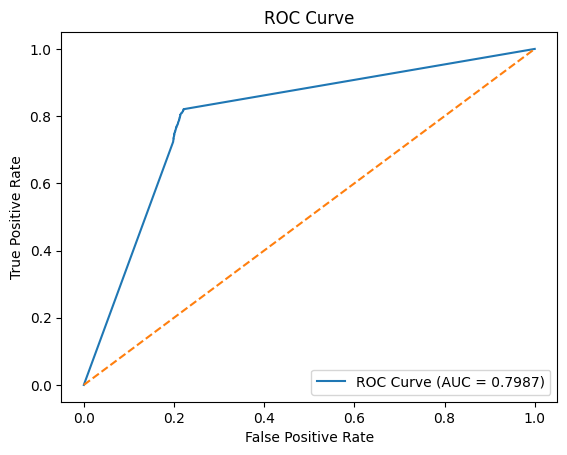

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_true, probs_np)

# Compute AUC (optional, since you already have it)
roc_auc_value = auc(fpr, tpr)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_value:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")  # random baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.show()